# 02. Когорты селлеров: Retention, ARPPS, LTV

удерживаются ли селлеры и сколько денег приносит
один привлечённый селлер за полгода жизни.

Когорта определяется месяцем первого заказа. Считаем 2мя способами:
по `date_created` и по `date_paid`, потому что это разные бизнес-события
и цифры будут отличаться.

In [14]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.db import get_engine, query, save_mart
from src import viz

viz.setup()
engine = get_engine()

## 1. Загружаем когорты

In [15]:
def load_cohorts(date_col):
    df = query(engine, "cohorts_sellers.sql", date_col=date_col)
    df["cohort_month"] = pd.to_datetime(df.cohort_month)
    df["activity_month"] = pd.to_datetime(df.activity_month)
    df["month_number"] = viz.month_number(df.cohort_month, df.activity_month)
    df["arpps"] = df.gmv / df.sellers
    return df

coh_created = load_cohorts("date_created")
coh_paid = load_cohorts("date_paid")

coh_created.head()

,cohort_month,activity_month,sellers,gmv,margin,month_number,arpps
0,2017-01-01,2017-01-01,214,112080.31,28967.2819,1,523.739766
1,2017-01-01,2017-02-01,161,131119.14,33474.2490,2,814.404596
2,2017-01-01,2017-03-01,159,182196.42,48434.0555,3,1145.889434
3,2017-01-01,2017-04-01,137,166753.66,43250.4653,4,1217.180000
4,2017-01-01,2017-05-01,143,219681.95,60367.9750,5,1536.237413


Номер месяца жизни считается по календарной разнице, а не через
`row_number()` в SQL.

## 2. Retention Rate

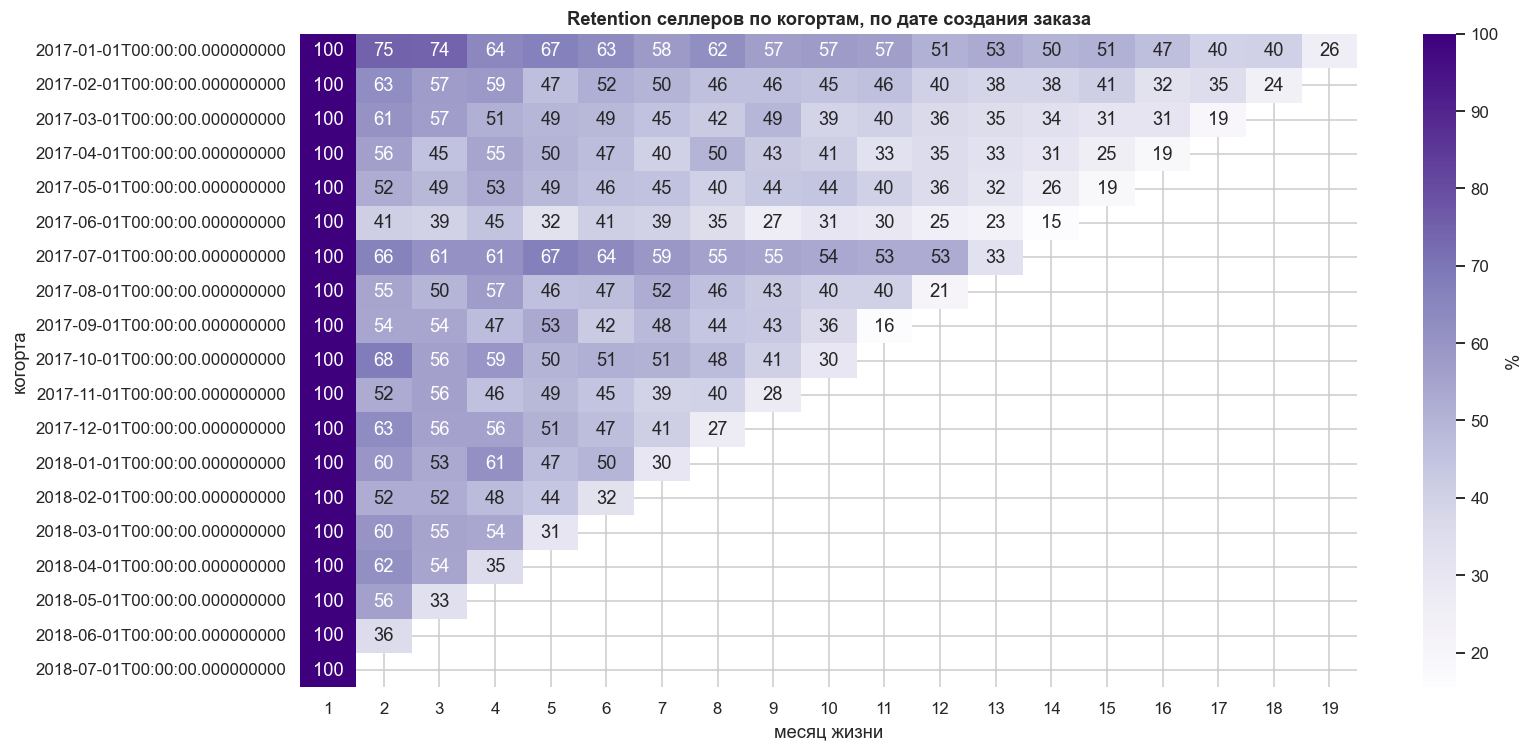

In [16]:
def retention(df):
    pt = df.pivot_table(index="cohort_month", columns="month_number", values="sellers")
    return pt.div(pt[1], axis=0) * 100

rr_created = retention(coh_created)
rr_paid = retention(coh_paid)

plt.figure(figsize=(15, 7))
sns.heatmap(rr_created, annot=True, fmt=".0f", cmap="Purples", cbar_kws={"label": "%"})
plt.title("Retention селлеров по когортам, по дате создания заказа")
plt.xlabel("месяц жизни")
plt.ylabel("когорта")
plt.tight_layout()
plt.show()

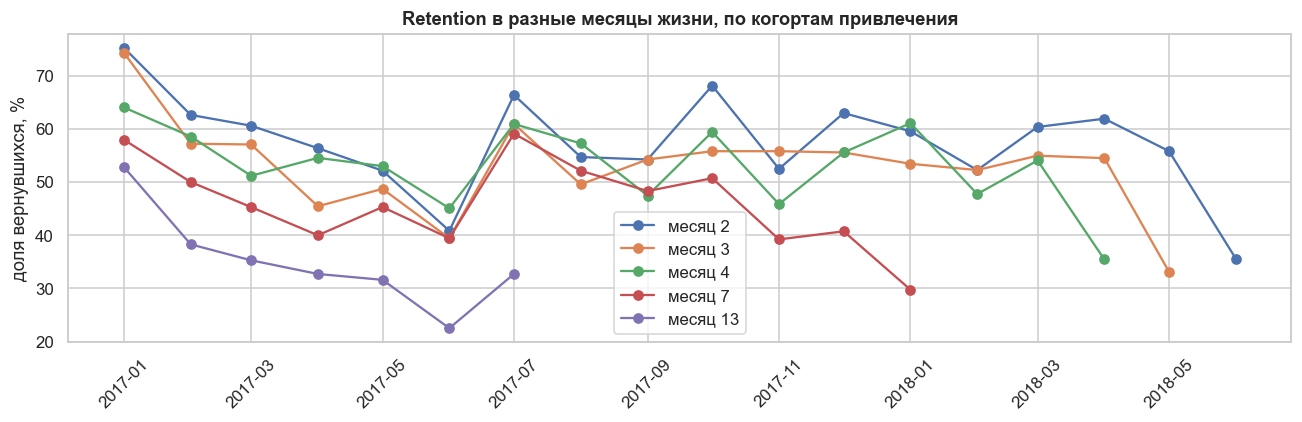

In [17]:
plt.figure(figsize=(12, 4))
for m in [2, 3, 4, 7, 13]:
    if m in rr_created.columns:
        plt.plot(rr_created.index, rr_created[m], marker="o", label=f"месяц {m}")
plt.legend()
plt.title("Retention в разные месяцы жизни, по когортам привлечения")
plt.ylabel("доля вернувшихся, %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Retention created против paid

In [18]:
compare = pd.DataFrame({
    "created_m2": rr_created.get(2),
    "paid_m2": rr_paid.get(2),
}).round(1)
compare

,created_m2,paid_m2
cohort_month,,
2017-01-01,75.2,80.1
2017-02-01,62.6,65.4
2017-03-01,60.6,58.2
2017-04-01,56.4,61.0
2017-05-01,52.1,48.8
2017-06-01,40.8,40.3
2017-07-01,66.4,60.7
2017-08-01,54.7,54.5
2017-09-01,54.2,54.5


## 4. ARPPS по когортам

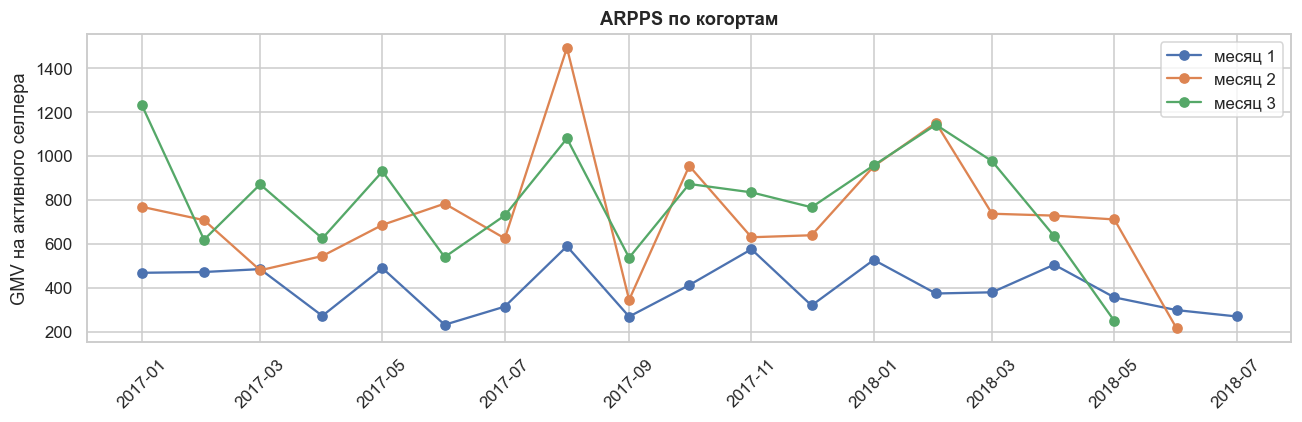

In [19]:
arpps = coh_paid.pivot_table(index="cohort_month", columns="month_number", values="arpps")

plt.figure(figsize=(12, 4))
for m in [1, 2, 3]:
    if m in arpps.columns:
        plt.plot(arpps.index, arpps[m], marker="o", label=f"месяц {m}")
plt.legend()
plt.title("ARPPS по когортам")
plt.ylabel("GMV на активного селлера")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. LTV

In [20]:
HORIZON = 6  

sellers_pt = coh_paid.pivot_table(index="cohort_month", columns="month_number", values="sellers")
margin_pt = coh_paid.pivot_table(index="cohort_month", columns="month_number", values="margin")
gmv_pt = coh_paid.pivot_table(index="cohort_month", columns="month_number", values="gmv")

mature = sellers_pt.index[sellers_pt.notna().sum(axis=1) >= HORIZON]

cohort_size = sellers_pt.loc[mature, 1]
ltv_margin = margin_pt.loc[mature, :HORIZON].sum(axis=1) / cohort_size
ltv_gmv = gmv_pt.loc[mature, :HORIZON].sum(axis=1) / cohort_size

ltv = pd.DataFrame({
    "cohort_size": cohort_size,
    f"gmv_per_seller_{HORIZON}m": ltv_gmv,
    f"ltv_margin_{HORIZON}m": ltv_margin,
}).round(1)
ltv

,cohort_size,gmv_per_seller_6m,ltv_margin_6m
cohort_month,,,
2017-01-01,176.0,4838.6,1306.5
2017-02-01,228.0,2650.5,645.1
2017-03-01,184.0,2496.4,620.2
2017-04-01,105.0,1901.4,525.0
2017-05-01,127.0,2532.5,619.9
2017-06-01,77.0,1205.3,307.6
2017-07-01,107.0,2835.4,706.3
2017-08-01,121.0,3415.0,628.6
2017-09-01,112.0,1666.4,433.3


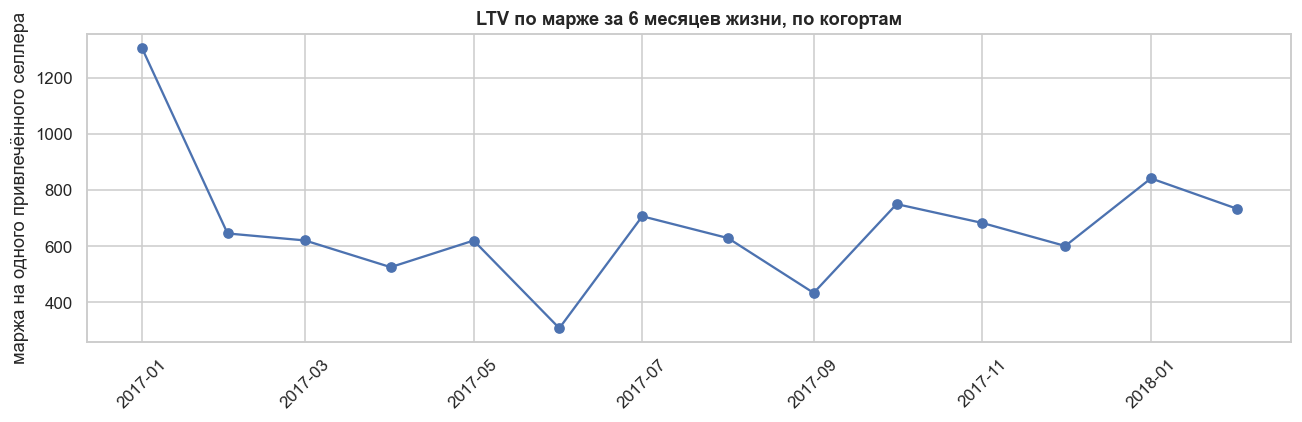

In [21]:
plt.figure(figsize=(12, 4))
plt.plot(ltv.index, ltv[f"ltv_margin_{HORIZON}m"], marker="o")
plt.title(f"LTV по марже за {HORIZON} месяцев жизни, по когортам")
plt.ylabel("маржа на одного привлечённого селлера")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Посчитаем LTV 2мя способами

In [22]:

wrong = arpps.loc[mature, :HORIZON].sum(axis=1)
right = ltv_gmv

pd.DataFrame({
    # сумма маржи когорты за горизонт, делённая на **исходный** размер когорты в первом месяце.
    "LTV1": right.round(1),
    # сумма ARPPS по месяцам жизни
    "LTV2": wrong.round(1),
    "завышение, %": ((wrong / right - 1) * 100).round(1),
})

,LTV1,LTV2,"завышение, %"
cohort_month,,,
2017-01-01,4838.6,6629.9,37.0
2017-02-01,2650.5,4335.5,63.6
2017-03-01,2496.4,4407.4,76.5
2017-04-01,1901.4,3400.5,78.8
2017-05-01,2532.5,4594.5,81.4
2017-06-01,1205.3,2619.6,117.3
2017-07-01,2835.4,4479.9,58.0
2017-08-01,3415.0,5898.1,72.7
2017-09-01,1666.4,3004.8,80.3


## 6. Сохраняем витрины

In [23]:
save_mart(rr_created.reset_index(), "retention_created")
save_mart(rr_paid.reset_index(), "retention_paid")
save_mart(arpps.reset_index(), "arpps_by_cohort")
save_mart(ltv.reset_index(), "ltv_by_cohort")

сохранено: data/marts/retention_created.csv, строк 19
сохранено: data/marts/retention_paid.csv, строк 19
сохранено: data/marts/arpps_by_cohort.csv, строк 19
сохранено: data/marts/ltv_by_cohort.csv, строк 14


PosixPath('/Users/m1/Desktop/marketplace-analytics/data/marts/ltv_by_cohort.csv')

## Выводы

1. Удержание стабильное: около 57% на второй месяц
2. Определение когорты по дате создания или по дате выкупа почти не влияет на результат. Разница retention второго месяца между двумя версиями в пределах ±5 п.п., без систематического смещения в одну сторону, для дальнейших расчётов можно брать любую версию, я взяла paid, потому что LTV считается по марже, а маржа возникает в момент выкупа.
3. Ограничения: нет CAC, молодые когорты исключены из расчёта LTV. Маржа на одного привлечённого селлера за 6 месяцев: от 307 (июнь 2017) до 841 (январь 2018), медиана около 630. Когорта января 2017 с 1306 из сравнения выпадает по той же причине, что и её retention.
4. Способ расчёта LTV через сумму ARPPS завышает результат на 37–117%. Разрыв прямо связан с удержанием: у когорты с лучшим retention (январь 2017, 80.1%) завышение минимальное, 37%. У когорты с худшим (июнь 2017, 40.3%) максимальное, 117%